<a href="https://colab.research.google.com/github/ArshadRatul/ML_Learning/blob/guest/Learning_New_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import kagglehub

path = kagglehub.dataset_download(
    "boiniabhiram/credit-card-fraud-detection"
)

print("Path to dataset files:", path)

print(os.listdir(path))


Using Colab cache for faster access to the 'credit-card-fraud-detection' dataset.
Path to dataset files: /kaggle/input/credit-card-fraud-detection
['creditcard.csv']


In [5]:
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/credit-card-fraud-detection/creditcard.csv


In [6]:
#all imports

import pandas as pd


import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler

from sklearn import svm
from sklearn.svm import SVC, LinearSVC
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

In [7]:
file_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(file_path)

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [8]:
print(df.describe())
print(df.info())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [9]:
X = df[df.columns[1:30]]
y = df[df.columns[-1]]

print(X)
print(y)

               V1         V2        V3        V4        V5        V6  \
0       -1.359807  -0.072781  2.536347  1.378155 -0.338321  0.462388   
1        1.191857   0.266151  0.166480  0.448154  0.060018 -0.082361   
2       -1.358354  -1.340163  1.773209  0.379780 -0.503198  1.800499   
3       -0.966272  -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4       -1.158233   0.877737  1.548718  0.403034 -0.407193  0.095921   
...           ...        ...       ...       ...       ...       ...   
284802 -11.881118  10.071785 -9.834783 -2.066656 -5.364473 -2.606837   
284803  -0.732789  -0.055080  2.035030 -0.738589  0.868229  1.058415   
284804   1.919565  -0.301254 -3.249640 -0.557828  2.630515  3.031260   
284805  -0.240440   0.530483  0.702510  0.689799 -0.377961  0.623708   
284806  -0.533413  -0.189733  0.703337 -0.506271 -0.012546 -0.649617   

              V7        V8        V9       V10  ...       V20       V21  \
0       0.239599  0.098698  0.363787  0.090794  ...  0.25141

In [10]:
#spliting data into 80-20 train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [11]:
X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
2557,-2.289565,-0.480260,0.818685,-1.706423,0.822102,-1.660326,0.944047,-0.541765,1.323156,-0.434426,...,-0.831985,-0.210837,0.914737,0.867888,0.422969,0.310584,-0.781488,0.392241,-0.147757,1.00
247823,-0.313717,-4.064342,-3.398445,0.704011,0.101662,1.529848,1.551670,-0.036774,0.015829,-0.359561,...,2.142593,0.853186,-0.091941,-0.936215,-0.833081,-0.498728,0.651183,-0.290331,0.110360,1194.28
152342,-1.809763,-0.567439,2.265186,-0.960318,-1.212537,1.516493,-1.417176,0.903421,1.961027,-0.724328,...,-0.554004,-0.509915,-0.424978,-0.268621,0.010121,0.466862,0.835540,-0.062385,0.088079,75.00
103385,1.192319,0.178575,0.141491,0.459628,-0.049959,-0.112122,-0.163883,0.155740,-0.067566,-0.130220,...,-0.149985,-0.240464,-0.739862,0.116799,-0.373837,0.125470,0.130126,-0.016956,0.011937,1.98
8771,-0.963451,0.700311,1.097333,-1.547626,0.669966,0.513533,0.333683,0.270900,1.381880,-0.659956,...,0.122458,-0.279519,-0.470181,-0.124037,-1.388839,-0.237453,0.785347,0.349708,0.216207,37.31


In [12]:
#Normalization
X_train_normalized = MinMaxScaler().fit_transform(X_train)
X_test_normalized = MinMaxScaler().fit_transform(X_test)

X_train_standardized = StandardScaler().fit_transform(X_train)
X_test_standardized = StandardScaler().fit_transform(X_test)


print("X_Train_normalized", X_train_normalized)
print("X_Test_normalized", X_test_normalized)

print("X_Train_standardized", X_train_normalized)
print("X_Test_standardized", X_test_normalized)

X_Train_normalized [[9.19396895e-01 7.62190917e-01 9.35842557e-01 ... 2.47846766e-01
  3.10125428e-01 3.89238944e-05]
 [9.52964118e-01 7.24373557e-01 8.55536773e-01 ... 2.31402183e-01
  3.15363409e-01 4.64860287e-02]
 [9.27548142e-01 7.61271047e-01 9.63387918e-01 ... 2.36893876e-01
  3.14911251e-01 2.91929208e-03]
 ...
 [9.55803074e-01 7.77735416e-01 9.49284959e-01 ... 2.35478371e-01
  3.09142458e-01 1.53360144e-04]
 [9.08200066e-01 7.92105507e-01 8.72241909e-01 ... 2.50368503e-01
  3.19938719e-01 3.89238944e-05]
 [9.79243884e-01 7.58977035e-01 9.27617965e-01 ... 2.38426174e-01
  3.13906932e-01 4.39840007e-03]]
X_Test_normalized [[5.25824841e-01 8.14718958e-01 3.49045387e-01 ... 6.46815483e-01
  3.83185993e-01 3.64190000e-02]
 [9.47511538e-01 6.51781618e-01 7.79009635e-01 ... 7.11650043e-01
  4.24307446e-01 5.20120000e-02]
 [9.74007799e-01 6.82748165e-01 7.86038515e-01 ... 7.10718650e-01
  4.20808813e-01 3.10000000e-03]
 ...
 [9.57686926e-01 6.76457879e-01 8.08312900e-01 ... 7.12196424

In [13]:
#SVM

# 1. One-vs-One (OvO) Strategy
# Default for standard SVC. Trains N*(N-1)/2 binary classifiers.
svm_ovo = SVC(decision_function_shape='ovo', kernel="rbf")
svm_ovo.fit(X_train_normalized,y_train)
y_pred_ovo = svm_ovo.predict(X_test_normalized)

# 2. One-vs-Rest (OvR) Strategy
# Explicitly sets OvR behavior in standard SVC. Trains N binary classifiers.
svm_ovr = SVC(decision_function_shape='ovr', kernel='rbf')
svm_ovr.fit(X_train_normalized, y_train)
y_pred_ovr = svm_ovr.predict(X_test_normalized)

# 3. LinearSVC (Optimized for linear boundary, uses OvR by default)
# Faster than SVC(kernel='linear') on large datasets.
svm_linear = LinearSVC(multi_class='ovr', random_state=42)
svm_linear.fit(X_train_normalized, y_train)
y_pred_linear = svm_linear.predict(X_test_normalized)

In [14]:
print(y_pred_ovo)

print(y_pred_ovr)

print(y_pred_linear)

[1 0 0 ... 0 0 0]
[1 0 0 ... 0 0 0]
[1 0 0 ... 0 0 0]


Confusion Matrix:
[[85295    12]
 [   55    81]]


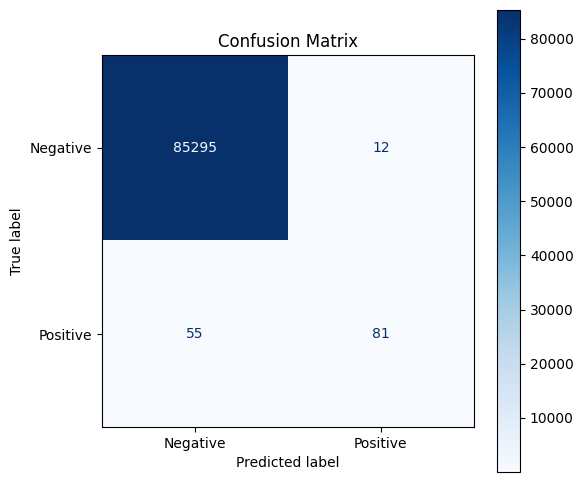

Precision: 0.8710
Recall:    0.5956
F1-Score:  0.7074


In [15]:
# 4. Calculate Single-Value Metrics
cm = confusion_matrix(y_test, y_pred_ovo)
prec = precision_score(y_test, y_pred_ovo)
rec = recall_score(y_test, y_pred_ovo)
f1 = f1_score(y_test, y_pred_ovo)




print(f"Confusion Matrix:\n{cm}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Confusion Matrix')
plt.grid(False)  # Turn off grid overlay for clean image rendering
plt.show()
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")


Confusion Matrix:
[[85295    12]
 [   55    81]]


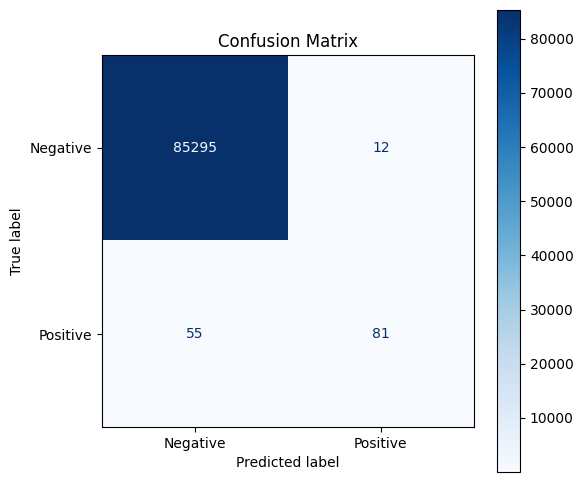

Precision:  0.8710
Recall:    0.5956
F1-Score:  0.7074


In [17]:
# 4. Calculate Single-Value Metrics
cm = confusion_matrix(y_test, y_pred_ovr)
prec = precision_score(y_test, y_pred_ovr)
rec = recall_score(y_test, y_pred_ovr)
f1 = f1_score(y_test, y_pred_ovr)




print(f"Confusion Matrix:\n{cm}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Confusion Matrix')
plt.grid(False)  # Turn off grid overlay for clean image rendering
plt.show()
print(f"Precision: {prec: .4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")


Confusion Matrix:
[[85298     9]
 [   87    49]]


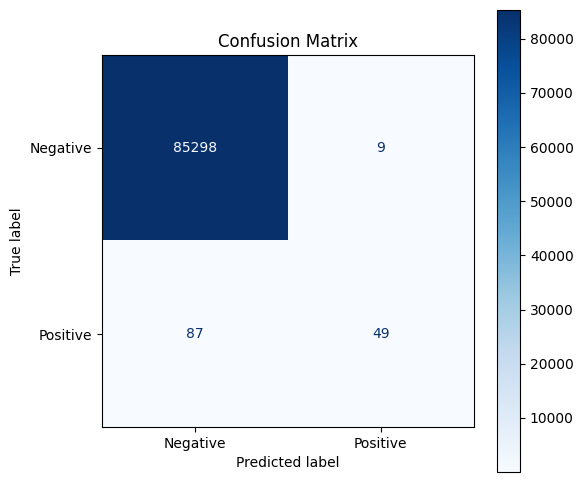

Precision: 0.8448
Recall:    0.3603
F1-Score:  0.5052


In [18]:
# 4. Calculate Single-Value Metrics
cm = confusion_matrix(y_test, y_pred_linear)
prec = precision_score(y_test, y_pred_linear)
rec = recall_score(y_test, y_pred_linear)
f1 = f1_score(y_test, y_pred_linear)




print(f"Confusion Matrix:\n{cm}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Confusion Matrix')
plt.grid(False)  # Turn off grid overlay for clean image rendering
plt.show()
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
